In [1]:
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("thyroid_dataset.csv")

In [3]:
df.sample(3)

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
3824,0.66,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0.00030,16.0,0.12,91.0,132.0,n
2546,0.92,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00014,9.0,92.00,91.0,101.0,n
219,0.87,0,0,0,0,0,0,0,0,0,...,0,0,0,0,14.00000,17.0,89.00,101.0,88.0,o


In [4]:
df.shape

(6916, 22)

In [5]:
X = df.drop("Outlier_label",axis=1)
y = df["Outlier_label"]

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
# Isolation Forest :

from sklearn.ensemble import IsolationForest

IF = IsolationForest(
    n_estimators=200,
    contamination='auto',
    random_state=42
)

In [8]:
labels = IF.fit_predict(X_scaled)

In [9]:
# PCA :

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

Anomaly Count : 270


<Axes: >

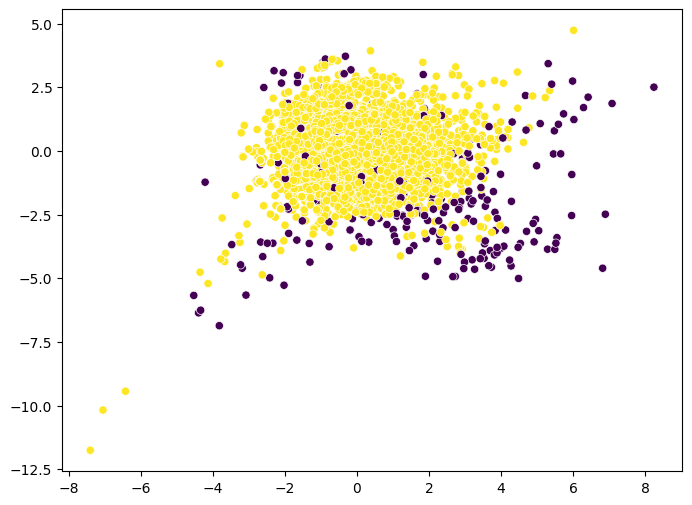

In [11]:
import numpy as np
print(f"Anomaly Count : {np.sum(labels==-1)}")

plt.figure(figsize=(8,6))

sns.scatterplot(x=X_pca[:,0],y=X_pca[:,1],c=labels)

Anomaly Count : 249


<Axes: >

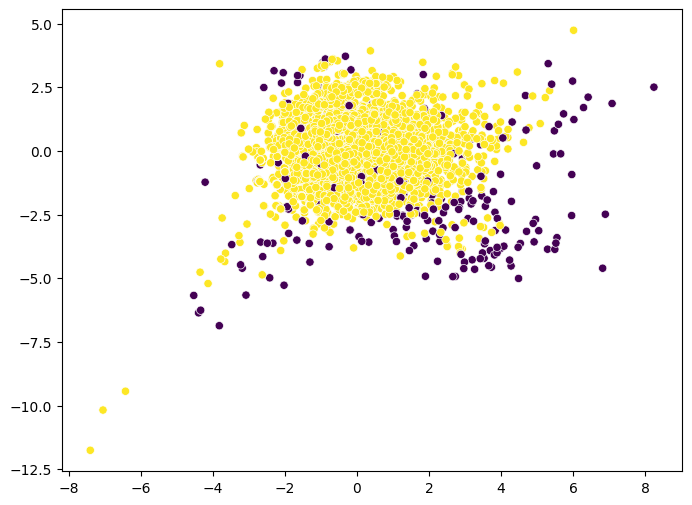

In [12]:
# Isolation Forest : (With known contamination)

from sklearn.ensemble import IsolationForest

IF = IsolationForest(
    n_estimators=200,
    contamination=0.036,
    random_state=42
)

labels = IF.fit_predict(X_scaled)

print(f"Anomaly Count : {np.sum(labels==-1)}")

plt.figure(figsize=(8,6))

sns.scatterplot(x=X_pca[:,0],y=X_pca[:,1],c=labels)